# Fase 3 - Camada Gold: Análise de Dados
Pipeline Viagens a Serviço (Portal da Transparência) - Arquitetura Medallion

Este notebook consome a camada **Silver** já carregada no PostgreSQL, responde
perguntas de negócio com SQL + tabela + gráfico, e constrói a camada **Gold**
agregada (tabela e VIEW, via JOIN + GROUP BY).

# =========================================================================
# SPRINT 3 - ANÁLISE DE DADOS
# Análise da base de dados com base na camada Silver e camda gold.
# =========================================================================


In [ ]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().resolve().parent))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from banco import conectar, executar

conn = conectar()
pd.set_option("display.max_columns", None)


def formatar_real(valor):
    """Formata um numero como moeda brasileira: R$ 1.234.567,89"""
    if pd.isna(valor):
        return ""
    texto = f"{valor:,.2f}"
    texto = texto.replace(",", "X").replace(".", ",").replace("X", ".")
    return f"R$ {texto}"


def formatar_tabela_reais(df, colunas):
    """Retorna uma copia do DataFrame com as colunas indicadas formatadas em R$.
    O DataFrame original nao e alterado (mantem os valores numericos, uteis
    para os graficos)."""
    df_fmt = df.copy()
    for col in colunas:
        if col in df_fmt.columns:
            df_fmt[col] = df_fmt[col].apply(formatar_real)
    return df_fmt


def formatar_eixo_reais(ax, eixo="x"):
    """Formata os ticks de um eixo do grafico (matplotlib) em R$, mantendo
    os dados numericos originais para o desenho das barras."""
    formatter = mticker.FuncFormatter(lambda valor, pos: formatar_real(valor))
    if eixo == "x":
        ax.xaxis.set_major_formatter(formatter)
    else:
        ax.yaxis.set_major_formatter(formatter)


## Perguntas de negócio - Parte 1 (direto da camada Silver)

### 1) Quais são os 5 órgãos com maior custo total?

In [ ]:
sql_q1 = '''
SELECT nome_orgao_superior, SUM(valor_total) AS custo_total
FROM silver_viagem
GROUP BY nome_orgao_superior
ORDER BY custo_total DESC
LIMIT 5;
'''
df_q1 = pd.read_sql(sql_q1, conn)
formatar_tabela_reais(df_q1, ["custo_total"])

/tmp/ipykernel_3609/1407560605.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_q1 = pd.read_sql(sql_q1, conn)


,nome_orgao_superior,custo_total
0,Ministério da Justiça e Segurança Pública,4.869331e+08
1,Ministério da Defesa,1.560703e+08
2,Ministério da Educação,1.112913e+08
3,Ministério do Meio Ambiente e Mudança do Clima,4.969771e+07
4,Ministério da Previdência Social,4.041731e+07


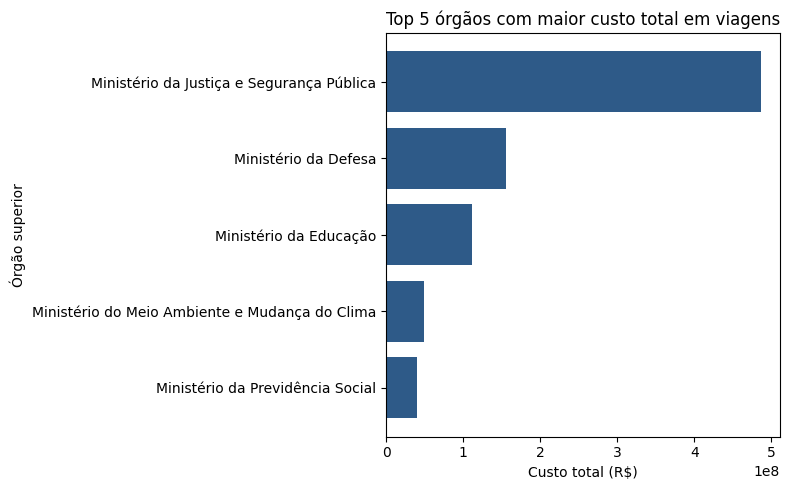

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(df_q1['nome_orgao_superior'], df_q1['custo_total'], color='#2E5A88')
ax.set_xlabel('Custo total (R$)')
ax.set_ylabel('Órgão superior')
ax.set_title('Top 5 órgãos com maior custo total em viagens')
ax.invert_yaxis()
formatar_eixo_reais(ax, eixo="x")
plt.tight_layout()
plt.show()

### 2) Quais são os 3 destinos com maior custo médio por viagem?

In [ ]:
sql_q2 = '''
SELECT t.destino_uf || ' - ' || t.destino_cidade AS destino,
       AVG(v.valor_total) AS custo_medio,
       COUNT(DISTINCT v.id_viagem) AS qtd_viagens
FROM silver_trecho t
JOIN silver_viagem v ON v.id_viagem = t.id_viagem
WHERE t.destino_cidade IS NOT NULL
GROUP BY t.destino_uf, t.destino_cidade
HAVING COUNT(DISTINCT v.id_viagem) >= 5
ORDER BY custo_medio DESC
LIMIT 3;
'''
df_q2 = pd.read_sql(sql_q2, conn)
formatar_tabela_reais(df_q2, ["custo_medio"])

/tmp/ipykernel_3609/3081436391.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_q2 = pd.read_sql(sql_q2, conn)


,destino,custo_medio,qtd_viagens
0,Rondônia - Monte Negro,96133.261104,98
1,Rio Grande do Sul - Sananduva,95397.809286,103
2,Rio Grande do Sul - Nonoai,91901.186059,117


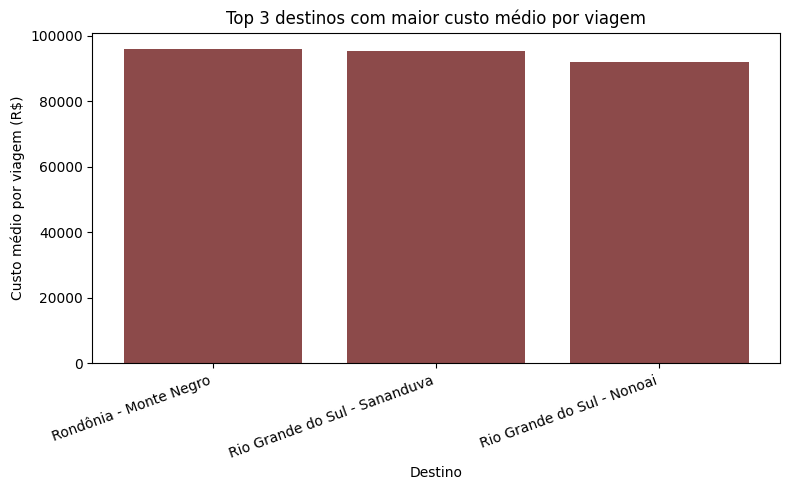

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(df_q2['destino'], df_q2['custo_medio'], color='#8C4A4A')
ax.set_xlabel('Destino')
ax.set_ylabel('Custo médio por viagem (R$)')
ax.set_title('Top 3 destinos com maior custo médio por viagem')
formatar_eixo_reais(ax, eixo="y")
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

### 3) Qual a viagem de maior duração e seu custo total?

In [ ]:
sql_q3 = '''
SELECT id_viagem, nome_viajante, nome_orgao_superior, data_inicio, data_fim,
       duracao_dias, valor_total
FROM silver_viagem
WHERE duracao_dias IS NOT NULL
ORDER BY duracao_dias DESC
LIMIT 1;
'''
df_q3 = pd.read_sql(sql_q3, conn)
formatar_tabela_reais(df_q3, ["valor_total"])

/tmp/ipykernel_3609/2517699268.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_q3 = pd.read_sql(sql_q3, conn)


,id_viagem,nome_viajante,nome_orgao_superior,data_inicio,data_fim,duracao_dias,valor_total
0,0000000000020699856,LUISANGELA CORREA FRANCO DE FARIA,Ministério da Previdência Social,2025-01-13,2026-01-31,383,0.0


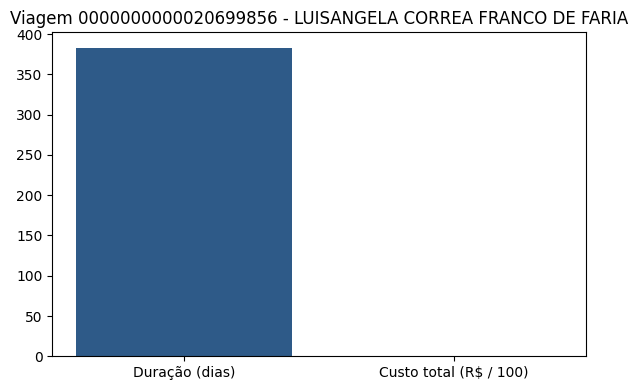

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
linha = df_q3.iloc[0]
ax.bar(['Duracao (dias)'], [linha['duracao_dias']], color='#2E5A88')
ax.set_ylabel('Duracao (dias)')
ax.set_title(
    f"Viagem {linha['id_viagem']} - {linha['nome_viajante']}\n"
    f"Custo total: {formatar_real(linha['valor_total'])}"
)
plt.tight_layout()
plt.show()

## Camada Gold agregada
Cria a tabela `gold_gastos_orgao` (JOIN entre `silver_viagem` e `silver_pagamento`,
agrupando por órgão pagador) e uma VIEW equivalente `vw_gold_gastos_orgao`.

In [ ]:
sql_gold_drop = "DROP TABLE IF EXISTS gold_gastos_orgao;"
executar(conn, sql_gold_drop)

sql_gold_table = '''
CREATE TABLE gold_gastos_orgao AS
SELECT
    p.nome_orgao_pagador,
    COUNT(DISTINCT v.id_viagem) AS qtd_viagens,
    SUM(p.valor) AS total_pago,
    AVG(p.valor) AS valor_medio_pagamento,
    SUM(v.duracao_dias) AS total_dias_viagem
FROM silver_viagem v
JOIN silver_pagamento p ON p.id_viagem = v.id_viagem
GROUP BY p.nome_orgao_pagador;
'''
executar(conn, sql_gold_table)

sql_gold_view = '''
CREATE OR REPLACE VIEW vw_gold_gastos_orgao AS
SELECT
    p.nome_orgao_pagador,
    COUNT(DISTINCT v.id_viagem) AS qtd_viagens,
    SUM(p.valor) AS total_pago,
    AVG(p.valor) AS valor_medio_pagamento,
    SUM(v.duracao_dias) AS total_dias_viagem
FROM silver_viagem v
JOIN silver_pagamento p ON p.id_viagem = v.id_viagem
GROUP BY p.nome_orgao_pagador;
'''
executar(conn, sql_gold_view)

df_gold = pd.read_sql('SELECT * FROM gold_gastos_orgao ORDER BY total_pago DESC;', conn)
formatar_tabela_reais(df_gold.head(10), ["total_pago", "valor_medio_pagamento"])


## Perguntas de negócio - Parte 2 (a partir da camada Gold)

### 4) Qual o tipo de pagamento com maior valor médio?

In [ ]:
sql_q4 = '''
SELECT tipo_pagamento, AVG(valor) AS valor_medio, COUNT(*) AS qtd
FROM silver_pagamento
GROUP BY tipo_pagamento
ORDER BY valor_medio DESC;
'''
df_q4 = pd.read_sql(sql_q4, conn)
formatar_tabela_reais(df_q4, ["valor_medio"])

/tmp/ipykernel_3609/752158358.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_q4 = pd.read_sql(sql_q4, conn)


,tipo_pagamento,valor_medio,qtd
0,DIÁRIAS,2078.280299,401463
1,PASSAGEM,1878.344393,188985
2,Serviço correlato: seguro,447.514653,4894
3,RESTITUIÇÃO,245.702610,11574


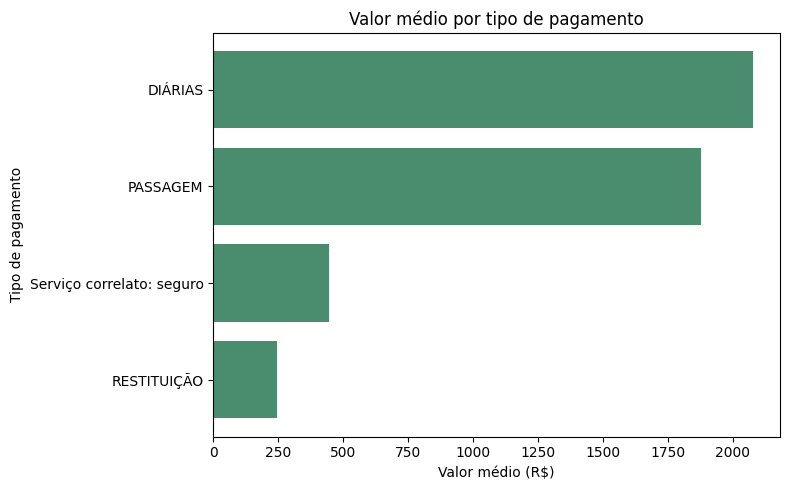

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(df_q4['tipo_pagamento'], df_q4['valor_medio'], color='#4A8C6E')
ax.set_xlabel('Valor médio (R$)')
ax.set_ylabel('Tipo de pagamento')
ax.set_title('Valor médio por tipo de pagamento')
ax.invert_yaxis()
formatar_eixo_reais(ax, eixo="x")
plt.tight_layout()
plt.show()

### 5) Qual o meio de transporte mais usado nos trechos?

In [11]:
sql_q5 = '''
SELECT meio_transporte, COUNT(*) AS qtd_trechos
FROM silver_trecho
WHERE meio_transporte IS NOT NULL
GROUP BY meio_transporte
ORDER BY qtd_trechos DESC;
'''
df_q5 = pd.read_sql(sql_q5, conn)
df_q5

/tmp/ipykernel_3609/2460505910.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_q5 = pd.read_sql(sql_q5, conn)


,meio_transporte,qtd_trechos
0,Veículo Oficial,386424
1,Aéreo,232666
2,Rodoviário,64970
3,Veículo Próprio,42846
4,Inválido,26659
5,Fluvial,8429
6,Ferroviário,874
7,Marítimo,481


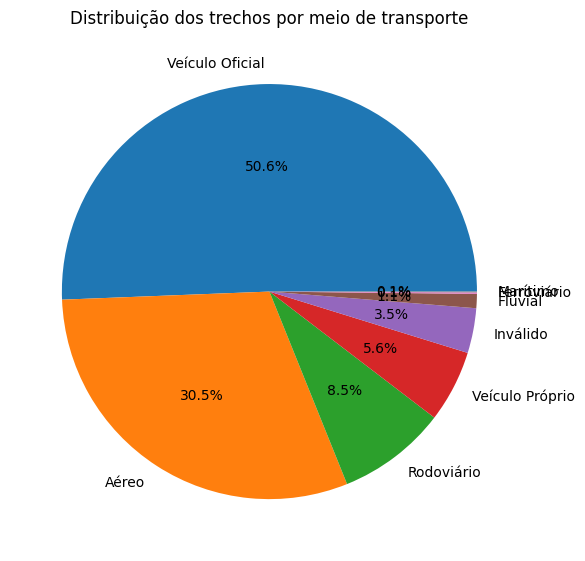

In [12]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(df_q5['qtd_trechos'], labels=df_q5['meio_transporte'], autopct='%1.1f%%')
ax.set_title('Distribuição dos trechos por meio de transporte')
plt.tight_layout()
plt.show()

### 6) Qual UF de destino aparece em mais trechos?

In [13]:
sql_q6 = '''
SELECT destino_uf, COUNT(*) AS qtd_trechos
FROM silver_trecho
WHERE destino_uf IS NOT NULL
GROUP BY destino_uf
ORDER BY qtd_trechos DESC
LIMIT 10;
'''
df_q6 = pd.read_sql(sql_q6, conn)
df_q6

/tmp/ipykernel_3609/2704934498.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_q6 = pd.read_sql(sql_q6, conn)


,destino_uf,qtd_trechos
0,São Paulo,82722
1,Distrito Federal,79962
2,Minas Gerais,50965
3,Rio de Janeiro,44197
4,Paraná,42603
5,Pará,40044
6,Rio Grande do Sul,38684
7,Mato Grosso do Sul,30516
8,Bahia,28375
9,Pernambuco,28372


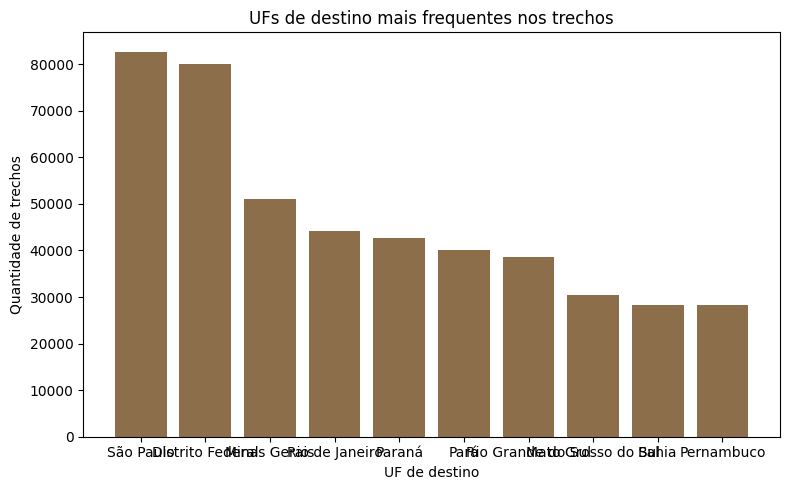

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(df_q6['destino_uf'], df_q6['qtd_trechos'], color='#8C6E4A')
ax.set_xlabel('UF de destino')
ax.set_ylabel('Quantidade de trechos')
ax.set_title('UFs de destino mais frequentes nos trechos')
plt.tight_layout()
plt.show()

### 7) Qual órgão pagou mais no total?

In [ ]:
sql_q7 = '''
SELECT nome_orgao_pagador, SUM(valor) AS total_pago
FROM silver_pagamento
GROUP BY nome_orgao_pagador
ORDER BY total_pago DESC
LIMIT 5;
'''
df_q7 = pd.read_sql(sql_q7, conn)
formatar_tabela_reais(df_q7, ["total_pago"])

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(df_q7['nome_orgao_pagador'], df_q7['total_pago'], color='#6E4A8C')
ax.set_xlabel('Total pago (R$)')
ax.set_ylabel('Órgão pagador')
ax.set_title('Top 5 órgãos que mais pagaram no total')
ax.invert_yaxis()
formatar_eixo_reais(ax, eixo="x")
plt.tight_layout()
plt.show()

## Conclusão

A análise da camada Gold sobre viagens a serviço do Portal da Transparência 
(jan-jun 2025) permitiu identificar os seguintes pontos principais:

**Custos e órgãos**
- O órgão com maior custo total em viagens foi Ministério de Justiça e Segurança Pública, somando R$ 486.933.121,65.
- O órgão que mais pagou no total (considerando todos os tipos de pagamento) 
  foi Fundo Nacional de Segurança Pública, com R$ 278.481.047,89.

**Destinos e deslocamento**
- Os destinos com maior custo médio por viagem foram Rondônio - Monte Negro, Rio Grande do Sul - Sananduva e Rio Grande do Sul - Nonoai
- SP foi o destino mais frequente nos trechos registrados do total.

**Duração e perfil das viagens**
- A viagem de maior duração durou 383 dias, custando R$ 0,00  realizada por LUISANGELA CORREA FRANCO DE FARIA a serviço de Ministério Previdencia Social.

**Pagamentos e transporte**
- O tipo de pagamento com maior valor médio foi Diárias.
- O meio de transporte predominante nos trechos foi o Veículo Oficial.

**Observação geral**
Chamou atenção a viagem de maior duração com custo zero.


In [2]:
conn.close()

NameError: name 'conn' is not defined